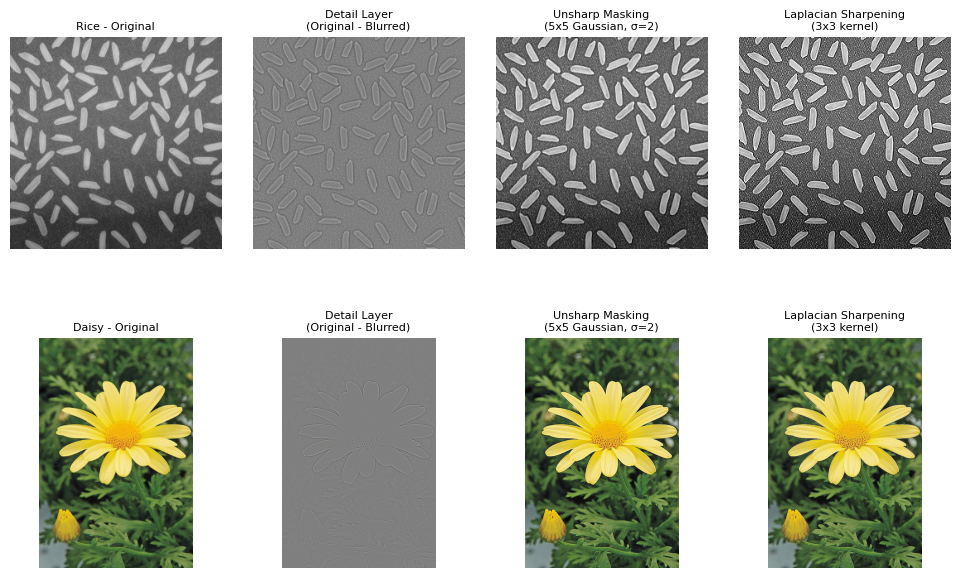

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("q9_outputs", exist_ok=True)

#Unsharp masking using Gaussian blur
def unsharp_mask(image, k=1.5):
    blurred = cv.GaussianBlur(image, (5, 5), 2)

    #signed detail layer
    detail = image.astype(np.int16) - blurred.astype(np.int16)

    #sharpened image
    sharpened = image.astype(np.int16) + k * detail
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return blurred, detail, sharpened

#Laplacian-style sharpening kernel
def laplacian_sharpen(image):
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    sharpened = cv.filter2D(image, -1, kernel)
    return sharpened

# -----------------------------------
# Selected images
# -----------------------------------
images = [
    ("/content/rice.png", "Rice"),
    ("/content/daisy.jpg", "Daisy")
]

all_results = []

# -----------------------------------
# Process each image
# -----------------------------------
for path, name in images:
    img = cv.imread(path)
    if img is None:
        print(f"Error loading {path}")
        continue

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Gaussian-based sharpening
    blurred, detail, unsharp = unsharp_mask(img, k=1.5)

    # Make detail layer visible for display
    detail_display = np.clip(detail + 128, 0, 255).astype(np.uint8)

    # Laplacian-style kernel sharpening
    lap_sharp = laplacian_sharpen(img)

    # Convert for display
    detail_rgb = cv.cvtColor(detail_display, cv.COLOR_BGR2RGB)
    unsharp_rgb = cv.cvtColor(unsharp, cv.COLOR_BGR2RGB)
    lap_sharp_rgb = cv.cvtColor(lap_sharp, cv.COLOR_BGR2RGB)

    # Save separate outputs
    cv.imwrite(f"q9_outputs/{name.lower()}_detail.png", detail_display)
    cv.imwrite(f"q9_outputs/{name.lower()}_unsharp.png", unsharp)
    cv.imwrite(f"q9_outputs/{name.lower()}_laplacian.png", lap_sharp)

    all_results.append({
        "name": name,
        "original": img_rgb,
        "detail": detail_rgb,
        "unsharp": unsharp_rgb,
        "laplacian": lap_sharp_rgb
    })

# -----------------------------------
# Save all results in one single picture
# -----------------------------------
rows = len(all_results)
cols = 4

plt.figure(figsize=(10, 3 * rows))

for i, data in enumerate(all_results):
    plt.subplot(rows, cols, i * cols + 1)
    plt.imshow(data["original"])
    plt.title(f"{data['name']} - Original", fontsize=8)
    plt.axis("off")

    plt.subplot(rows, cols, i * cols + 2)
    plt.imshow(data["detail"])
    plt.title("Detail Layer\n(Original - Blurred)", fontsize=8)
    plt.axis("off")

    plt.subplot(rows, cols, i * cols + 3)
    plt.imshow(data["unsharp"])
    plt.title("Unsharp Masking\n(5x5 Gaussian, σ=2)", fontsize=8)
    plt.axis("off")

    plt.subplot(rows, cols, i * cols + 4)
    plt.imshow(data["laplacian"])
    plt.title("Laplacian Sharpening\n(3x3 kernel)", fontsize=8)
    plt.axis("off")

plt.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.05, wspace=0.15, hspace=0.35)
plt.savefig("q9_outputs/q9_all_results.png", dpi=300, bbox_inches="tight")
plt.show()